<a href="https://colab.research.google.com/github/VANSHSAINI4499/payroll_pro/blob/main/Copy_of_ASL_Sign_Language_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ASL Sign Language Recognition — YOLOv8 + MediaPipe

Pipeline:
1.  Install dependencies
2. Download ASL dataset from Roboflow
3. Train YOLOv8 hand detector
4. Extract MediaPipe landmarks
5. Train gesture classifier (MLP)
6. Test inference on sample images



 Check GPU

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('⚠️  No GPU found! Go to Runtime → Change runtime type → T4 GPU')

CUDA available: True
GPU: Tesla T4
Memory: 15.64 GB


In [2]:
import sys
import subprocess

def pip_install(*packages):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])

pip_install('--upgrade', 'pip')
pip_install('ultralytics', 'roboflow', 'scikit-learn', 'pandas', 'matplotlib', 'opencv-python-headless')

# mediapipe wheels are version-sensitive; pick a compatible build
if sys.version_info >= (3, 11):
    mp_pkg = 'mediapipe==0.10.14'
else:
    mp_pkg = 'mediapipe==0.10.9'

pip_install(mp_pkg)
print('✅ All dependencies installed!')

✅ All dependencies installed!


In [3]:
import mediapipe as mp

print('mediapipe version:', getattr(mp, '__version__', 'unknown'))
print('mediapipe module:', getattr(mp, '__file__', 'unknown'))

if not hasattr(mp, 'solutions'):
    raise RuntimeError(
        'mediapipe imported without solutions. Restart the runtime and re-run the install cell.'
)

mediapipe version: 0.10.14
mediapipe module: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py


##  Install Dependencies

In [4]:
!pip install roboflow


## Download ASL Dataset from Roboflow

In [5]:
from roboflow import Roboflow
import os

API_KEY = 'rmHoBAGzpZSQH1TvGTf8'  # Your Roboflow API key

rf = Roboflow(api_key=API_KEY)
project = rf.workspace('david-lee-d0rhs').project('american-sign-language-letters')
dataset = project.version(1).download('yolov8', location='./data/roboflow_asl')

print(f'✅ Dataset downloaded to: {dataset.location}')
print(f'📊 Dataset: {dataset.name}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./data/roboflow_asl in yolov8:: 100%|██████████| 3468/3468 [00:00<00:00, 11973.22it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset downloaded to: /content/data/roboflow_asl
📊 Dataset: American Sign Language Letters


In [6]:
# Verify dataset structure
import os
for split in ['train', 'valid', 'test']:
    img_path = f'./data/roboflow_asl/{split}/images'
    if os.path.exists(img_path):
        count = len(os.listdir(img_path))
        print(f'  {split}: {count} images')
    else:
        print(f'  {split}: ❌ not found')

  train: 1512 images
  valid: 144 images
  test: 72 images


#Write data.yaml for YOLOv8

In [7]:
import os
import yaml

DATASET_PATH = os.path.abspath('./data/roboflow_asl')

data_yaml = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 26,
    'names': list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
}

os.makedirs('./configs', exist_ok=True)
with open('./configs/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print('✅ configs/data.yaml written')
print(f'   Dataset path: {DATASET_PATH}')

✅ configs/data.yaml written
   Dataset path: /content/data/roboflow_asl


In [8]:
!pip install ultralytics

## 4️⃣ Train YOLOv8 Hand Detector
> ⏱️ ~15–20 minutes with T4 GPU | 50 epochs

In [9]:
from ultralytics import YOLO
import torch

device = '0' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {device}')

model = YOLO('yolov8n.pt')  # nano model — fast and accurate

results = model.train(
    data='./configs/data.yaml',
    epochs=50,
    imgsz=640,
    batch=32,
    device=device,
    project='models/yolov8',
    name='sign_detect',
    workers=2,
    patience=10,
    exist_ok=True,
    plots=True,
    verbose=True,
)

print('\n✅ YOLOv8 Training Complete!')
print(f'Best weights: runs/detect/models/yolov8/sign_detect/weights/best.pt')

Training on: 0
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sign_detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [10]:
# Display training curves
from IPython.display import Image, display
import glob

for img in glob.glob('models/yolov8/sign_detect/*.png'):
    print(img)
    display(Image(img, width=800))

## 5️⃣ Validate YOLOv8 on Test Set

In [11]:
model = YOLO('runs/detect/models/yolov8/sign_detect/weights/best.pt')

metrics = model.val(
    data='./configs/data.yaml',
    split='test',
    conf=0.25,
    iou=0.5,
    plots=True,
)

print(f'\n📊 Test Results:')
print(f'   mAP@0.5:     {metrics.box.map50:.4f}')
print(f'   mAP@0.5:0.95:{metrics.box.map:.4f}')
print(f'   Precision:   {metrics.box.mp:.4f}')
print(f'   Recall:      {metrics.box.mr:.4f}')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 643.0±357.9 MB/s, size: 13.7 KB)
val: Scanning /content/data/roboflow_asl/test/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 1.8Kit/s 0.0s
val: New cache created: /content/data/roboflow_asl/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.7s
                   all         72         72      0.843      0.877      0.862      0.704
                     A          1          1       0.25          1      0.995      0.895
                     B          3          3          1          1      0.995      0.813
                     C          4          4      0.845          1      0.995      0.871
                     D          1          1          1          1      0

In [12]:
!pip install mediapipe

## 6️⃣ Extract MediaPipe Landmarks from Training Images

In [13]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
from tqdm.notebook import tqdm

mp_hands = mp.solutions.hands

CLASS_NAMES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def extract_landmarks(image_path):
    """Extract 21 3D landmarks from a hand image using MediaPipe."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.3
    ) as hands:
        result = hands.process(img_rgb)
        if result.multi_hand_landmarks:
            lm = result.multi_hand_landmarks[0].landmark
            # Normalize relative to wrist (landmark 0)
            wrist = lm[0]
            coords = []
            for point in lm:
                coords.extend([point.x - wrist.x,
                                point.y - wrist.y,
                                point.z - wrist.z])
            return coords  # 63 features
    return None


def build_dataset(split='train'):
    img_dir = Path(f'./data/roboflow_asl/{split}/images')
    label_dir = Path(f'./data/roboflow_asl/{split}/labels')
    rows = []

    image_files = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    print(f'Processing {split}: {len(image_files)} images')

    for img_path in tqdm(image_files):
        # Get class from YOLO label file
        label_path = label_dir / (img_path.stem + '.txt')
        if not label_path.exists():
            continue
        with open(label_path) as f:
            first_line = f.readline().strip()
        if not first_line:
            continue
        class_id = int(first_line.split()[0])

        coords = extract_landmarks(img_path)
        if coords is not None:
            rows.append(coords + [CLASS_NAMES[class_id]])

    cols = [f'f{i}' for i in range(63)] + ['label']
    return pd.DataFrame(rows, columns=cols)


os.makedirs('./data/processed', exist_ok=True)

df_train = build_dataset('train')
df_val   = build_dataset('valid')
df_test  = build_dataset('test')

train_csv = './data/processed/train_landmarks.csv'
val_csv = './data/processed/val_landmarks.csv'
test_csv = './data/processed/test_landmarks.csv'

df_train.to_csv(train_csv, index=False)
df_val.to_csv(val_csv, index=False)
df_test.to_csv(test_csv, index=False)

print(f'\n✅ Landmarks extracted!')
print(f'   Train: {len(df_train)} samples')
print(f'   Val:   {len(df_val)} samples')
print(f'   Test:  {len(df_test)} samples')
print('\nSaved files:')
print(' -', train_csv)
print(' -', val_csv)
print(' -', test_csv)

# Download CSV files to your PC (Colab)
try:
    from google.colab import files  # type: ignore
    files.download(train_csv)
    files.download(val_csv)
    files.download(test_csv)
    print('✅ Downloads started in Colab')
except Exception as e:
    print('⚠️ Not running in Colab or download failed:', e)
    print('You can manually download from ./data/processed/')

Processing train: 1512 images


  0%|          | 0/1512 [00:00<?, ?it/s]

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.


Processing valid: 144 images


  0%|          | 0/144 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started in Colab


## 7️⃣ Train MLP Gesture Classifier

In [14]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_train = pd.read_csv('./data/processed/train_landmarks.csv')
df_val   = pd.read_csv('./data/processed/val_landmarks.csv')
df_test  = pd.read_csv('./data/processed/test_landmarks.csv')

feature_cols = [c for c in df_train.columns if c != 'label']

X_train = df_train[feature_cols].values
y_train = df_train['label'].values
X_val   = df_val[feature_cols].values
y_val   = df_val['label'].values
X_test  = df_test[feature_cols].values
y_test  = df_test['label'].values

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f'Training samples: {len(X_train)}')
print(f'Classes: {le.classes_}')

# Train MLP
print('\nTraining MLP classifier...')
clf = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=True,
)
clf.fit(X_train, y_train_enc)

# Evaluate
train_acc = accuracy_score(y_train_enc, clf.predict(X_train))
val_acc   = accuracy_score(y_val_enc,   clf.predict(X_val))
test_acc  = accuracy_score(y_test_enc,  clf.predict(X_test))

print(f'\n📊 Accuracy:')
print(f'   Train: {train_acc:.4f}')
print(f'   Val:   {val_acc:.4f}')
print(f'   Test:  {test_acc:.4f}')

print('\n📊 Classification Report (Test):')
# Get the unique classes actually present in the test set
present_classes_in_test = le.inverse_transform(np.unique(y_test_enc))
print(classification_report(y_test_enc, clf.predict(X_test), target_names=present_classes_in_test))


Training samples: 1251
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

Training MLP classifier...
Iteration 1, loss = 2.90420640
Validation score: 0.293651
Iteration 2, loss = 2.04382677
Validation score: 0.492063
Iteration 3, loss = 1.36068964
Validation score: 0.706349
Iteration 4, loss = 0.91738362
Validation score: 0.809524
Iteration 5, loss = 0.67039476
Validation score: 0.809524
Iteration 6, loss = 0.55514681
Validation score: 0.801587
Iteration 7, loss = 0.45909450
Validation score: 0.825397
Iteration 8, loss = 0.35049076
Validation score: 0.880952
Iteration 9, loss = 0.30159795
Validation score: 0.880952
Iteration 10, loss = 0.25343686
Validation score: 0.920635
Iteration 11, loss = 0.19646447
Validation score: 0.904762
Iteration 12, loss = 0.17730750
Validation score: 0.880952
Iteration 13, loss = 0.15300609
Validation score: 0.896825
Iteration 14, loss = 0.14318904
Validation score: 0.920635
Iteration 15, los

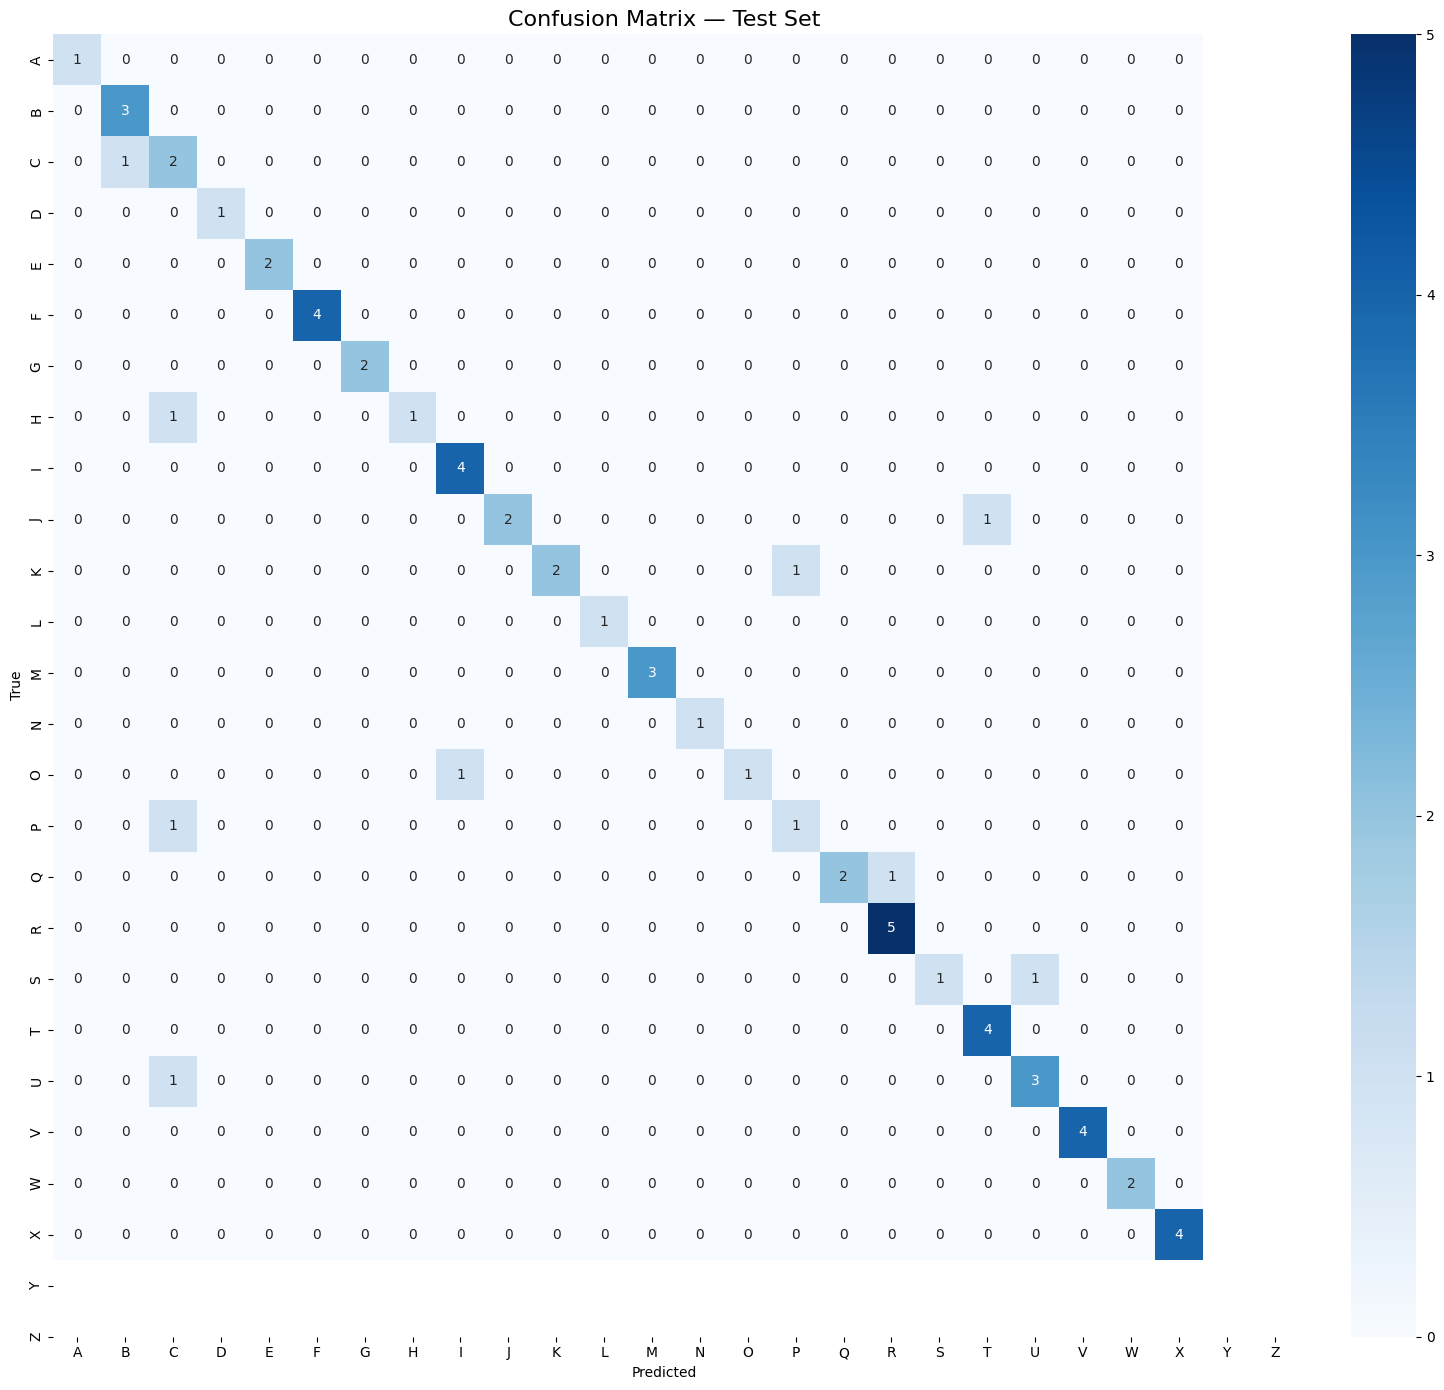

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test_enc, clf.predict(X_test))
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('./confusion_matrix.png', dpi=120)
plt.show()

In [16]:
# Save the trained models
os.makedirs('./models/classifier', exist_ok=True)

with open('./models/classifier/landmark_clf.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('./models/classifier/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('./models/classifier/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅ Models saved to ./models/classifier/')
print('   - landmark_clf.pkl')
print('   - scaler.pkl')
print('   - label_encoder.pkl')

✅ Models saved to ./models/classifier/
   - landmark_clf.pkl
   - scaler.pkl
   - label_encoder.pkl


## 8️⃣ Test Inference on Sample Images

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() inst

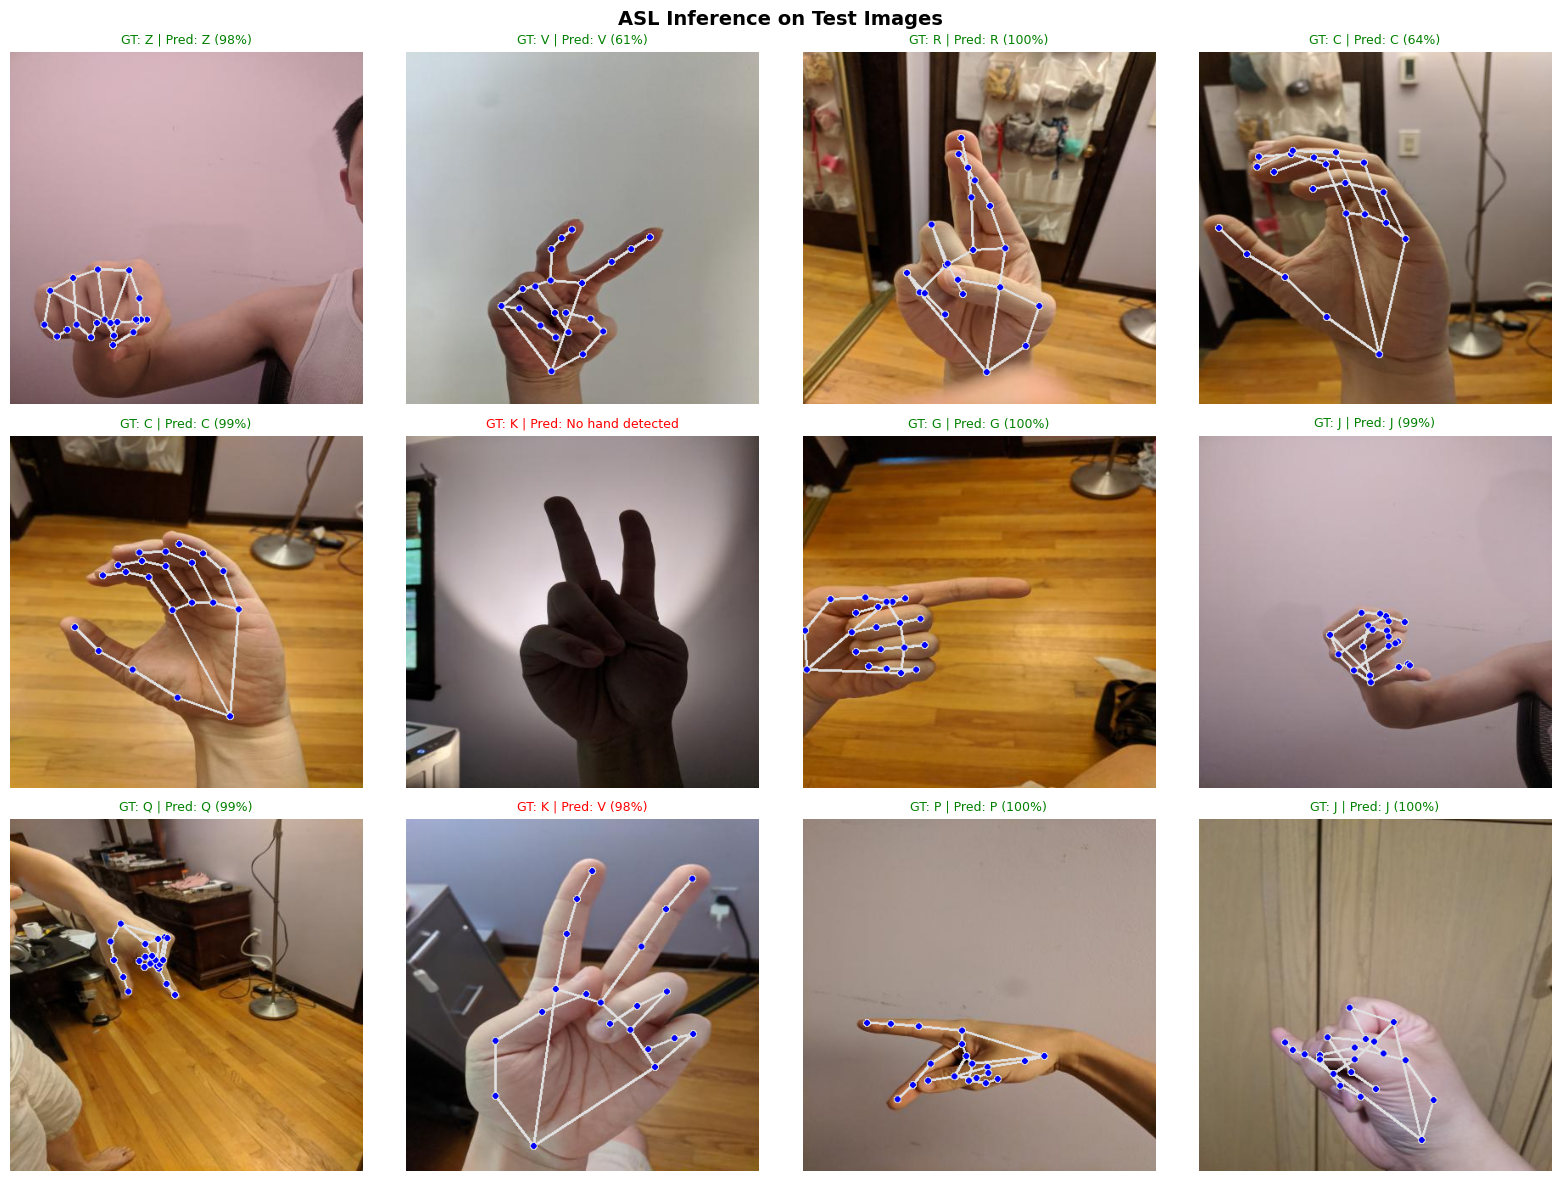

✅ Inference complete! Results saved to inference_results.png


In [17]:
from ultralytics import YOLO
import mediapipe as mp
import cv2
import numpy as np
import pickle
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# Load models
yolo_model = YOLO('runs/detect/models/yolov8/sign_detect/weights/best.pt')
with open('./models/classifier/landmark_clf.pkl', 'rb') as f:
    clf = pickle.load(f)
with open('./models/classifier/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('./models/classifier/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils


def predict_sign(image_path, conf_threshold=0.3):
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                        min_detection_confidence=0.3) as hands:
        result = hands.process(img_rgb)

    if result.multi_hand_landmarks:
        lm = result.multi_hand_landmarks[0].landmark
        wrist = lm[0]
        coords = []
        for point in lm:
            coords.extend([point.x - wrist.x, point.y - wrist.y, point.z - wrist.z])
        X = scaler.transform([coords])
        proba = clf.predict_proba(X)[0]
        class_idx = np.argmax(proba)
        confidence = proba[class_idx]
        label = le.inverse_transform([class_idx])[0]
        # Draw landmarks
        mp_draw.draw_landmarks(img_rgb, result.multi_hand_landmarks[0],
                               mp_hands.HAND_CONNECTIONS)
        return img_rgb, f'{label} ({confidence:.0%})'
    return img_rgb, 'No hand detected'


# Test on some sample images
test_images = list(Path('./data/roboflow_asl/test/images').glob('*.jpg'))[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, test_images):
    # Get ground truth from label
    label_path = Path('./data/roboflow_asl/test/labels') / (img_path.stem + '.txt')
    gt = '?'
    if label_path.exists():
        with open(label_path) as f:
            line = f.readline().strip()
        if line:
            gt = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')[int(line.split()[0])]

    img_result, prediction = predict_sign(img_path)
    if img_result is not None:
        ax.imshow(img_result)
        color = 'green' if prediction and prediction[0] == gt else 'red'
        ax.set_title(f'GT: {gt} | Pred: {prediction}', fontsize=9, color=color)
    ax.axis('off')

plt.suptitle('ASL Inference on Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./inference_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Inference complete! Results saved to inference_results.png')

## 9️⃣ Download Trained Models to your PC
Run this to zip and download everything you need.

In [18]:
import shutil
from google.colab import files

# Zip the trained models
shutil.make_archive('asl_models', 'zip', '.', 'models')
files.download('asl_models.zip')
print('✅ Download started! Save asl_models.zip to your project folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Save asl_models.zip to your project folder.


## 🔟 Results & Analysis (Run After Section 9️⃣)

Use this section **after you finish training** (sections 1–9). It assumes these variables already exist:
- `clf`, `le`, `scaler`
- `X_train`, `X_val`, `X_test`
- `y_train_enc`, `y_val_enc`, `y_test_enc`

It will print training details, compute metrics, and plot curves + confusion matrix.

In [20]:
# ===== Results Setup + Training Details (from existing model) =====

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Try to reuse in-memory variables; if missing, load from disk
required_vars = [
    "clf", "le", "X_train", "X_val", "X_test",
    "y_train_enc", "y_val_enc", "y_test_enc"
]
missing = [v for v in required_vars if v not in globals()]

if missing:
    print("Missing in-memory variables:", missing)
    print("Loading models and data from disk...")

    # Load models
    with open('./models/classifier/landmark_clf.pkl', 'rb') as f:
        clf = pickle.load(f)
    with open('./models/classifier/label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)

    # Load processed landmark data
    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    df_train = pd.read_csv('./data/processed/train_landmarks.csv')
    df_val   = pd.read_csv('./data/processed/val_landmarks.csv')
    df_test  = pd.read_csv('./data/processed/test_landmarks.csv')

    feature_cols = [c for c in df_train.columns if c != 'label']

    X_train = df_train[feature_cols].values
    y_train = df_train['label'].values
    X_val   = df_val[feature_cols].values
    y_val   = df_val['label'].values
    X_test  = df_test[feature_cols].values
    y_test  = df_test['label'].values

    # Scale features (use saved scaler if available)
    if os.path.exists('./models/classifier/scaler.pkl'):
        with open('./models/classifier/scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
        X_train = scaler.transform(X_train)
        X_val   = scaler.transform(X_val)
        X_test  = scaler.transform(X_test)
    else:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)
        X_test  = scaler.transform(X_test)

    # Encode labels using loaded label encoder
    y_train_enc = le.transform(y_train)
    y_val_enc   = le.transform(y_val)
    y_test_enc  = le.transform(y_test)

# Training details from the trained MLP
params = clf.get_params()

print("TRAINING DETAILS")
print("- Data split:")
print(f"  - Training set   : {len(X_train)} samples")
print(f"  - Validation set : {len(X_val)} samples")
print(f"  - Test set       : {len(X_test)} samples")
print("- Hyperparameters (from clf):")
print(f"  - Epochs (max_iter) : {params.get('max_iter')}")
print(f"  - Batch size        : {params.get('batch_size')}")
print(f"  - Learning rate     : {params.get('learning_rate_init')}")
print("- Early stopping:")
print(f"  - Enabled           : {params.get('early_stopping')}")
print(f"  - Monitor           : validation score (MLP early_stopping)")
print(f"  - Patience          : {params.get('n_iter_no_change')}")

# Evaluate on test set

y_pred = clf.predict(X_test)

test_acc = accuracy_score(y_test_enc, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_enc, y_pred, average="macro", zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test_enc, y_pred, average="weighted", zero_division=0
)

print("\nEVALUATION METRICS (TEST)")
print(f"- Accuracy            : {test_acc:.4f}")
print(f"- Precision (macro)   : {prec_macro:.4f}")
print(f"- Recall (macro)      : {rec_macro:.4f}")
print(f"- F1-score (macro)    : {f1_macro:.4f}")
print(f"- Precision (weighted): {prec_weighted:.4f}")
print(f"- Recall (weighted)   : {rec_weighted:.4f}")
print(f"- F1-score (weighted) : {f1_weighted:.4f}")

print("\nClassification Report (Test)")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_, zero_division=0))

TRAINING DETAILS
- Data split:
  - Training set   : 1251 samples
  - Validation set : 136 samples
  - Test set       : 65 samples
- Hyperparameters (from clf):
  - Epochs (max_iter) : 300
  - Batch size        : 64
  - Learning rate     : 0.001
- Early stopping:
  - Enabled           : True
  - Monitor           : validation score (MLP early_stopping)
  - Patience          : 15

EVALUATION METRICS (TEST)
- Accuracy            : 0.8615
- Precision (macro)   : 0.9097
- Recall (macro)      : 0.8507
- F1-score (macro)    : 0.8623
- Precision (weighted): 0.8926
- Recall (weighted)   : 0.8615
- F1-score (weighted) : 0.8604

Classification Report (Test)


ValueError: Number of classes, 24, does not match size of target_names, 26. Try specifying the labels parameter

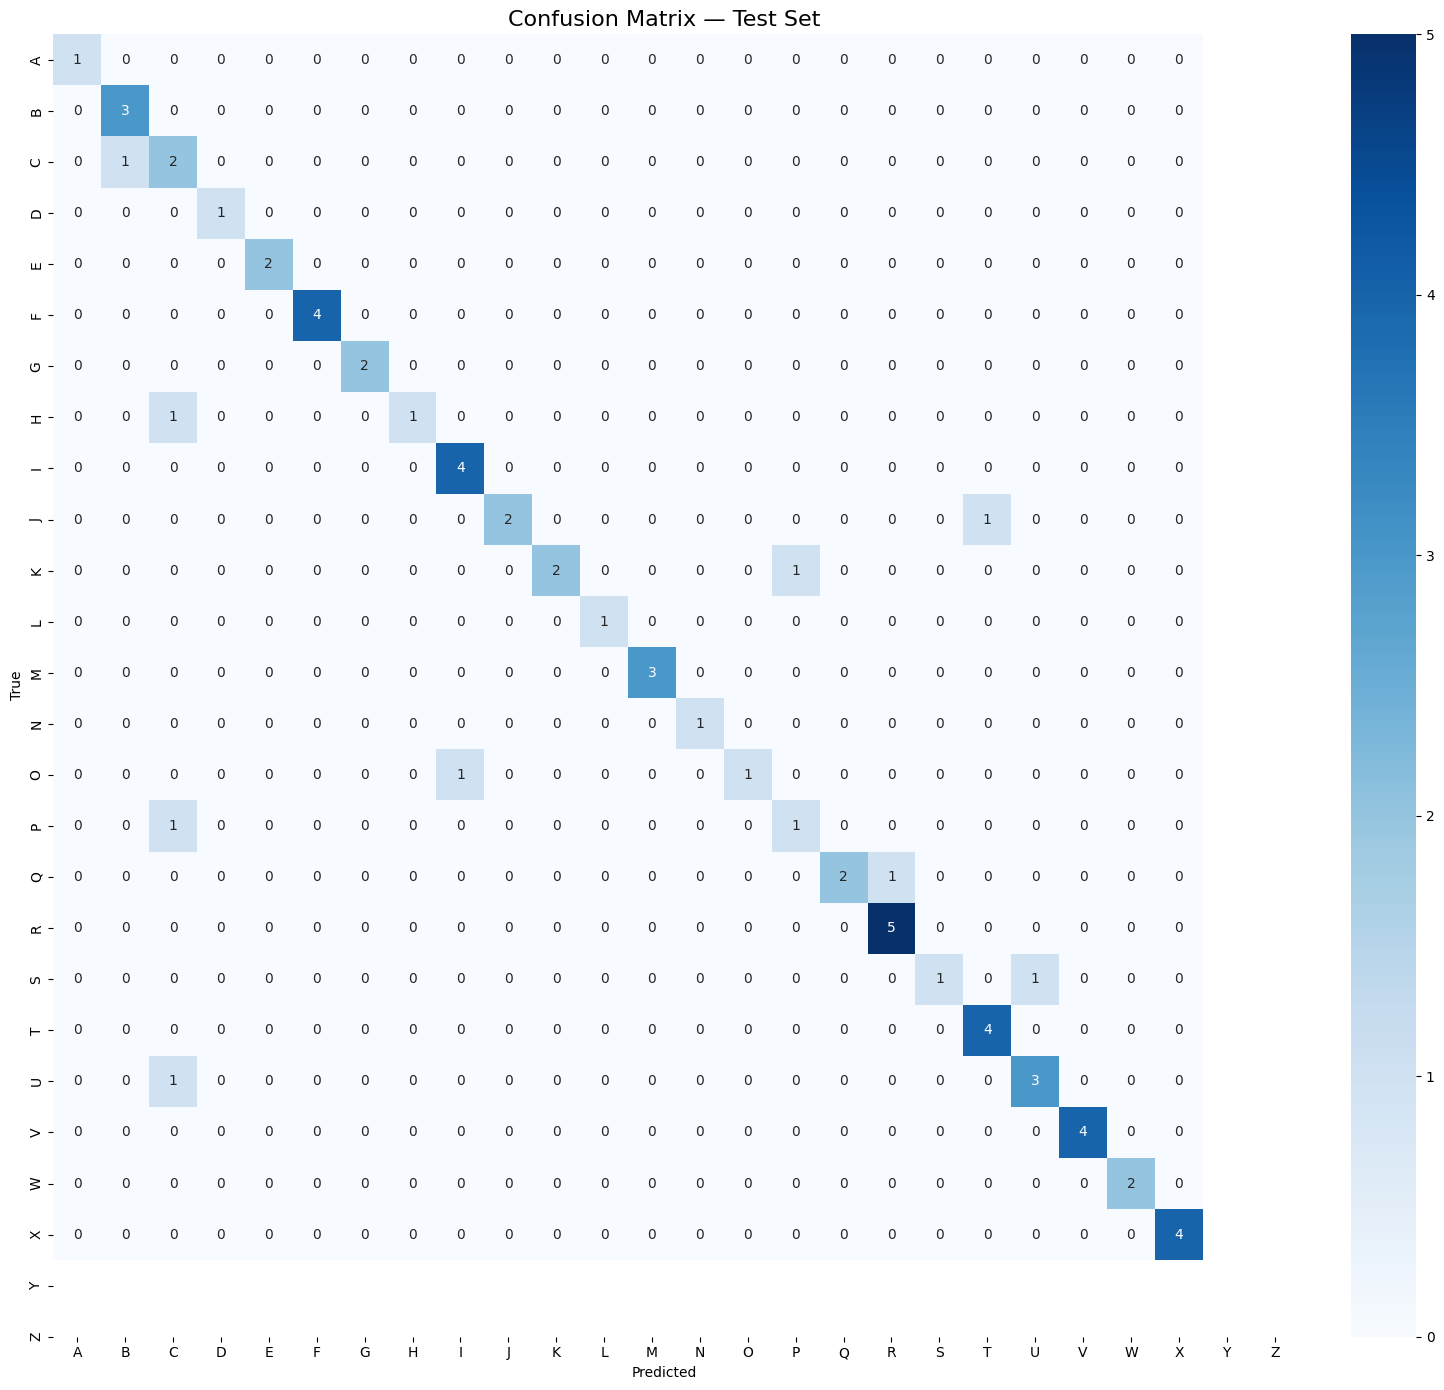

✅ Saved confusion matrix to ./confusion_matrix_post9.png


In [21]:
# ===== Confusion Matrix (Test Set) =====

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('./confusion_matrix_post9.png', dpi=120)
plt.show()
print('✅ Saved confusion matrix to ./confusion_matrix_post9.png')

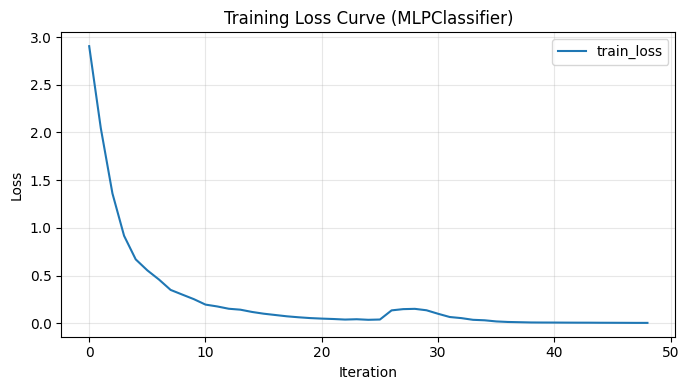

✅ Saved loss curve to ./loss_curve_post9.png


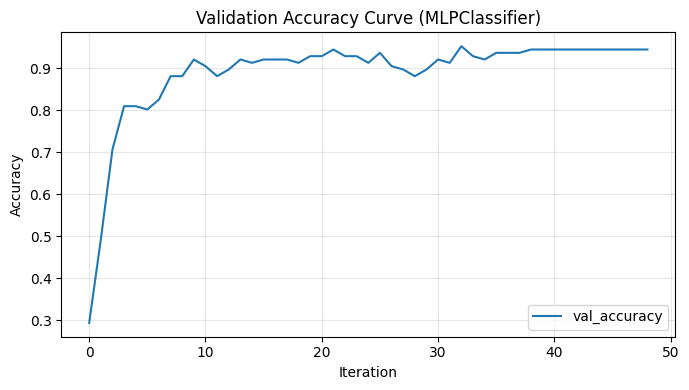

✅ Saved validation accuracy curve to ./val_accuracy_curve_post9.png


In [22]:
# ===== Training vs Validation Curves (from clf) =====

# Loss curve (available for MLPClassifier)
if hasattr(clf, "loss_curve_"):
    plt.figure(figsize=(7, 4))
    plt.plot(clf.loss_curve_, label="train_loss")
    plt.title("Training Loss Curve (MLPClassifier)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./loss_curve_post9.png', dpi=120)
    plt.show()
    print('✅ Saved loss curve to ./loss_curve_post9.png')
else:
    print("loss_curve_ not available on clf")

# Validation accuracy curve (only if early_stopping=True)
if hasattr(clf, "validation_scores_"):
    plt.figure(figsize=(7, 4))
    plt.plot(clf.validation_scores_, label="val_accuracy")
    plt.title("Validation Accuracy Curve (MLPClassifier)")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./val_accuracy_curve_post9.png', dpi=120)
    plt.show()
    print('✅ Saved validation accuracy curve to ./val_accuracy_curve_post9.png')
else:
    print("validation_scores_ not available on clf (enable early_stopping=True)")

In [23]:
# ===== Results Summary (Copy/Paste into document.txt) =====

epochs_ran = getattr(clf, "n_iter_", None)

print("TRAINING DETAILS")
print("- Data split:")
print(f"  - Training set   : {len(X_train)} samples")
print(f"  - Validation set : {len(X_val)} samples")
print(f"  - Test set       : {len(X_test)} samples")
print("- Hyperparameters:")
print(f"  - Epochs (max_iter) : {params.get('max_iter')} (ran {epochs_ran})")
print(f"  - Batch size        : {params.get('batch_size')}")
print(f"  - Learning rate     : {params.get('learning_rate_init')}")
print("- Early stopping:")
print(f"  - Enabled           : {params.get('early_stopping')}")
print(f"  - Patience          : {params.get('n_iter_no_change')}")

print("\nEVALUATION METRICS (TEST)")
print(f"- Accuracy            : {test_acc:.4f}")
print(f"- Precision (macro)   : {prec_macro:.4f}")
print(f"- Recall (macro)      : {rec_macro:.4f}")
print(f"- F1-score (macro)    : {f1_macro:.4f}")
print(f"- Precision (weighted): {prec_weighted:.4f}")
print(f"- Recall (weighted)   : {rec_weighted:.4f}")
print(f"- F1-score (weighted) : {f1_weighted:.4f}")

print("\nRESULTS & ANALYSIS")
print("- Plots saved:")
print("  - ./loss_curve_post9.png")
print("  - ./val_accuracy_curve_post9.png (if available)")
print("  - ./confusion_matrix_post9.png")

TRAINING DETAILS
- Data split:
  - Training set   : 1251 samples
  - Validation set : 136 samples
  - Test set       : 65 samples
- Hyperparameters:
  - Epochs (max_iter) : 300 (ran 49)
  - Batch size        : 64
  - Learning rate     : 0.001
- Early stopping:
  - Enabled           : True
  - Patience          : 15

EVALUATION METRICS (TEST)
- Accuracy            : 0.8615
- Precision (macro)   : 0.9097
- Recall (macro)      : 0.8507
- F1-score (macro)    : 0.8623
- Precision (weighted): 0.8926
- Recall (weighted)   : 0.8615
- F1-score (weighted) : 0.8604

RESULTS & ANALYSIS
- Plots saved:
  - ./loss_curve_post9.png
  - ./val_accuracy_curve_post9.png (if available)
  - ./confusion_matrix_post9.png
